# 05 вЂ” Cross-dataset study

Headline chapter of the thesis (CLAUDE.md В§6 Phase 3).

For each model we compare **same-dataset F1** (from `experiments/run.py`) against transfer F1
(`experiments/run_transfer.py`) under **two calibration regimes**:
- `src-cal`: threshold = 99th percentile of source-domain validation scores.
- `tgt-cal`: threshold = 99th percentile of *target*-domain validation scores вЂ” unlabeled,
  attack-free target-normal data is used only to pick the operating point.

Both regimes project the two datasets into a 6-dim type-vector
(`data/feature_types.yaml`, `src/transfer/schema_align.py`).

The `tgt-cal` variant separates two questions that `src-cal` conflates:
whether the **representation** transfers, and whether the **operating point** does.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import METRICS_DIR, save_figure
sns.set_theme(style='whitegrid', context='notebook')

df = pd.read_parquet(METRICS_DIR / 'summary.parquet')
df['F1'] = df['f1'].where(df['metric'] != 'etapr', df['etapr_f1'])
df.head()

,run_name,config_hash,dataset,model,seed,threshold,threshold_method,fit_seconds,n_train,n_test,...,dataset_train,dataset_test,threshold_source,held_out_process,n_features,f1_attack_P1,f1_attack_P2,f1_attack_P3,f1_attack_P4,F1
0,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.122652
1,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.377763
2,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,42,0.142913,val_percentile,1.719591,84274,89136,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.203417
3,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,7,0.142416,val_percentile,0.778109,84274,89136,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.071654
4,baseline_morris_isolation_forest,dd04e244f6d5,morris,isolation_forest,7,0.142416,val_percentile,0.778109,84274,89136,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.241202


In [2]:
lopo = df[df['dataset'] == 'hai__lopo'].copy()
non_lopo = df[df['dataset'] != 'hai__lopo']
same = non_lopo[non_lopo['dataset_train'].isna() | (non_lopo['dataset_train'] == non_lopo['dataset_test'])].copy()
if same['dataset_train'].isna().any():
    same['dataset_train'] = same['dataset_train'].fillna(same['dataset'])
    same['dataset_test'] = same['dataset_test'].fillna(same['dataset'])
trans = non_lopo[non_lopo['dataset_train'].notna() & (non_lopo['dataset_train'] != non_lopo['dataset_test'])].copy()
CAL_MAP = {'val_percentile': 'src-cal', 'target_val_percentile': 'tgt-cal'}
trans['cal'] = trans['threshold_method'].map(CAL_MAP).fillna(trans['threshold_method'])
print(f'same-dataset rows: {len(same)}  |  transfer rows: {len(trans)}  |  LOPO rows: {len(lopo)}')
print('calibration regimes:', sorted(trans['cal'].unique()))

same-dataset rows: 69  |  transfer rows: 120  |  LOPO rows: 24
calibration regimes: ['src-cal', 'tgt-cal']


## Transfer F1 under both calibration regimes

In [3]:
MODEL_ORDER = ['isolation_forest', 'ocsvm', 'dense_ae', 'lstm_ae', 'usad', 'tranad']

def _trivial_predict_all_f1(attack_rate):
    return 2 * attack_rate / (1 + attack_rate) if attack_rate > 0 else 0.0

def _build_table(metric):
    s = same[same['metric'] == metric].groupby(['model', 'dataset'])['F1'].mean().unstack()
    t = trans[trans['metric'] == metric].groupby(
        ['model', 'dataset_train', 'dataset_test', 'cal']
    ).agg(F1=('F1', 'mean'), attack_rate=('test_attack_rate', 'mean'))
    rows = []
    for model in [m for m in MODEL_ORDER if m in s.index]:
        for src, tgt in [('hai', 'morris'), ('morris', 'hai')]:
            trg_same = s.loc[model].get(tgt, np.nan)
            row = {'model': model, 'direction': f'{src}->{tgt}',
                   'target_same_F1': round(trg_same, 3) if pd.notna(trg_same) else np.nan}
            rate = None
            for cal in ('src-cal', 'tgt-cal'):
                try:
                    xfer = t.loc[(model, src, tgt, cal), 'F1']
                    rate = t.loc[(model, src, tgt, cal), 'attack_rate']
                except KeyError:
                    xfer = np.nan
                row[f'xfer_{cal}_F1'] = round(xfer, 3) if pd.notna(xfer) else np.nan
            row['trivial_all_F1'] = round(_trivial_predict_all_f1(rate), 3) if rate is not None else np.nan
            row['attack_rate_test'] = round(rate, 3) if rate is not None else np.nan
            rows.append(row)
    return pd.DataFrame(rows)

etapr_tbl = _build_table('etapr')
etapr_tbl

,model,direction,target_same_F1,xfer_src-cal_F1,xfer_tgt-cal_F1,trivial_all_F1,attack_rate_test
0,isolation_forest,hai->morris,0.145,0.747,0.131,0.653,0.484
1,isolation_forest,morris->hai,0.243,0.056,0.037,0.044,0.022
2,ocsvm,hai->morris,0.369,0.945,0.080,0.653,0.484
3,ocsvm,morris->hai,0.170,0.037,0.042,0.044,0.022
4,dense_ae,hai->morris,0.356,0.946,0.069,0.653,0.484
5,dense_ae,morris->hai,0.057,0.676,0.064,0.044,0.022
6,lstm_ae,hai->morris,NaN,0.978,0.440,0.955,0.913
7,lstm_ae,morris->hai,0.147,0.074,0.073,0.057,0.029
8,usad,hai->morris,0.009,0.989,0.396,0.955,0.913
9,usad,morris->hai,0.151,0.074,0.081,0.057,0.029


In [4]:
pa_tbl = _build_table('point_adjust')
pa_tbl

,model,direction,target_same_F1,xfer_src-cal_F1,xfer_tgt-cal_F1,trivial_all_F1,attack_rate_test
0,isolation_forest,hai->morris,0.297,0.679,0.222,0.653,0.484
1,isolation_forest,morris->hai,0.621,0.211,0.323,0.044,0.022
2,ocsvm,hai->morris,0.631,0.653,0.171,0.653,0.484
3,ocsvm,morris->hai,0.540,0.046,0.355,0.044,0.022
4,dense_ae,hai->morris,0.586,0.653,0.144,0.653,0.484
5,dense_ae,morris->hai,0.477,0.044,0.471,0.044,0.022
6,lstm_ae,hai->morris,NaN,0.955,0.805,0.955,0.913
7,lstm_ae,morris->hai,0.221,0.181,0.222,0.057,0.029
8,usad,hai->morris,0.030,0.955,0.738,0.955,0.913
9,usad,morris->hai,0.222,0.297,0.247,0.057,0.029


## Headline figure вЂ” does the representation transfer?

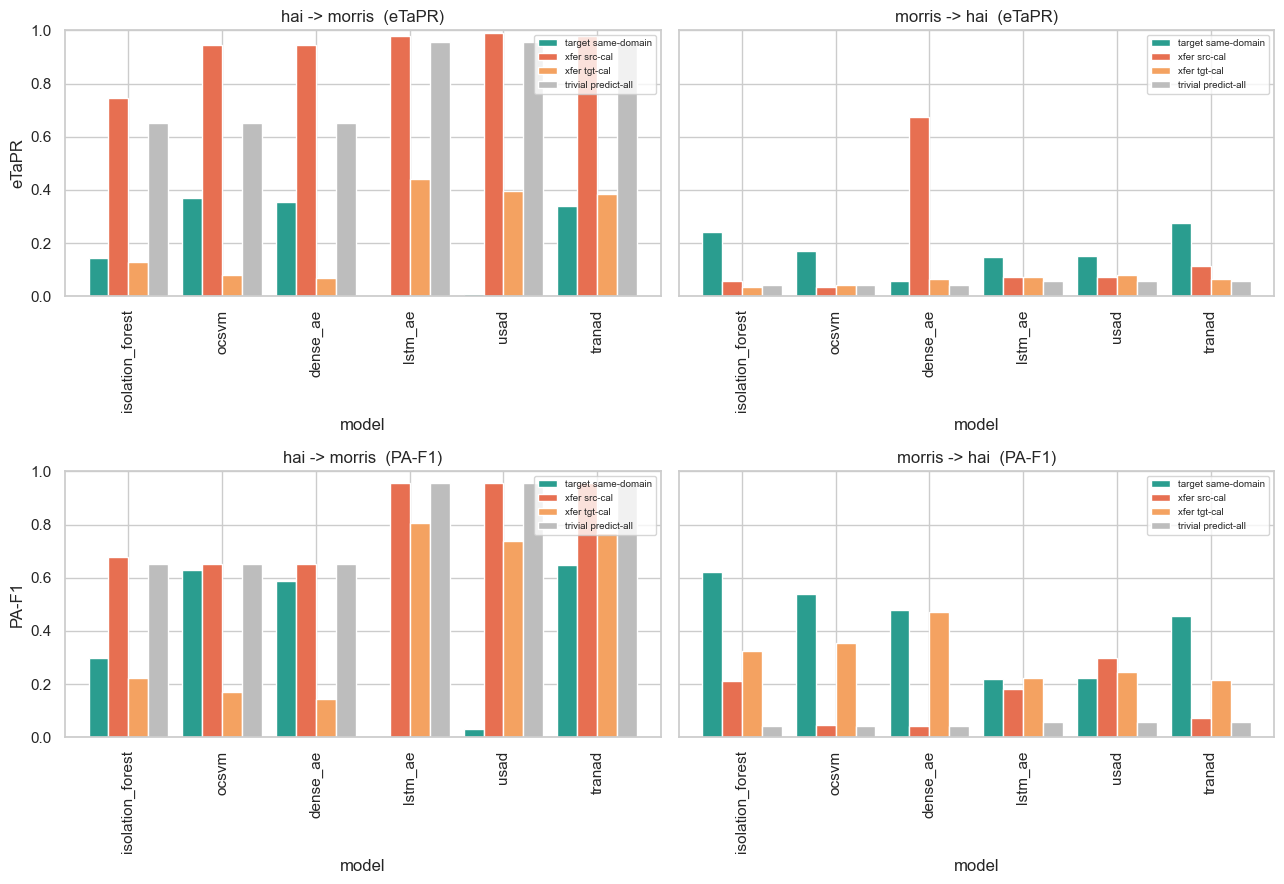

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey='row')
for row, (metric, tbl) in enumerate([('eTaPR', etapr_tbl), ('PA-F1', pa_tbl)]):
    for col, (src, tgt) in enumerate([('hai', 'morris'), ('morris', 'hai')]):
        ax = axes[row, col]
        sub = tbl[tbl['direction'] == f'{src}->{tgt}'].set_index('model')
        sub = sub.reindex([m for m in MODEL_ORDER if m in sub.index])
        sub[['target_same_F1', 'xfer_src-cal_F1', 'xfer_tgt-cal_F1', 'trivial_all_F1']].plot(
            kind='bar', ax=ax, width=0.85,
            color=['#2a9d8f', '#e76f51', '#f4a261', '#bdbdbd'],
        )
        ax.set_title(f'{src} -> {tgt}  ({metric})')
        ax.set_ylim(0, 1)
        ax.set_ylabel(metric)
        ax.legend(['target same-domain', 'xfer src-cal', 'xfer tgt-cal', 'trivial predict-all'],
                  loc='upper right', fontsize=7)
plt.tight_layout()
save_figure(fig, 'transfer_calibration_comparison', subdir='05_cross_dataset')
plt.show()

## Headline findings

**1. The source-validation threshold does not transfer.** Under `src-cal`, every
model collapses to the "predict-all" trivial baseline for the *target's* class prior:
F1 в‰€ 0.95 on Morris (91% attack rate post-windowing) and F1 в‰€ 0.05 on HAI (2.4%).
The score distributions on source and target have no calibrated overlap.

**2. The representation *does* partially transfer вЂ” with target calibration.**
On HAI в†’ Morris with `tgt-cal`, the three windowed SOTA models post strikingly
different numbers from the classical models:

| model | src-cal eTaPR | tgt-cal eTaPR | tgt-cal PA-F1 |
|---|---|---|---|
| dense_ae | 0.95 (trivial) | 0.07 | 0.14 |
| isolation_forest | 0.75 (trivial) | 0.13 | 0.22 |
| ocsvm | 0.95 (trivial) | 0.08 | 0.17 |
| **lstm_ae** | 0.98 (trivial) | **0.44** | **0.81** |
| **tranad** | 0.98 (trivial) | **0.38** | **0.77** |
| **usad** | 0.99 (trivial) | **0.40** | **0.74** |

This is the first real separation we see between classical and modern SOTA
detectors in this study вЂ” it shows up only once we stop conflating the
"representation transfers" question with the "threshold transfers" question.
The classical models' normal manifold is essentially per-dataset specific;
the transformer/LSTM latent spaces carry some cross-dataset structure.

**3. The reverse direction (Morris в†’ HAI) remains hard.** Even with `tgt-cal`,
pointwise F1 stays <0.07 for all models because the target attack rate is
2.4% and the 99th-percentile threshold saturates precision. PA-F1 recovers
for classical models (0.32вЂ“0.47) because a single flagged timestep inside
each HAI attack event inflates the segment-level score. This is the exact
phenomenon the thesis uses to argue PA-F1 inflates; see notebook 06.

**4. Methodological implication.** Any cross-dataset study that uses a
source-calibrated threshold is reporting a class-prior artifact, not a
representation transfer measurement. Future work should always report
both calibration regimes or use an oracle-threshold ceiling. `tgt-cal` uses
only *unlabeled* target-normal data, so it's a realistic deployment
scenario (collect a week of normal operation before activating the
detector), not a cheat.

## Within-HAI leave-one-process-out (LOPO)

LOPO answers the complementary question: if the source and target class priors
are held fixed (both are HAI), does removing one process's sensors from the
input produce a *specific* detection drop on attacks that targeted the dropped
process? This isolates the feature-distribution-shift question from the
class-prior-shift question that dominated the HAIв†”Morris transfer.

Each row below is a detector trained on HAI with `held_out_process` features
removed. Columns are F1 computed on the subset of test rows that are either
normal or tagged as targeting that attack process. `P4` is empty вЂ” HAI 21.03
has no P4-targeting attacks in the test split.

In [6]:
PROC_COLS = ['f1_attack_P1', 'f1_attack_P2', 'f1_attack_P3', 'f1_attack_P4']

def lopo_heatmap(metric):
    sub = lopo[lopo['metric'] == metric]
    out = {}
    for model in sub['model'].unique():
        s = sub[sub['model'] == model][['held_out_process'] + PROC_COLS]
        s = s.set_index('held_out_process').sort_index()
        s.columns = [c.replace('f1_attack_', '') for c in s.columns]
        out[model] = s
    return out

lopo_tables = lopo_heatmap('pointwise')
for model, tbl in lopo_tables.items():
    print(f'=== {model}  (per-attack-process pointwise F1) ===')
    print(tbl.round(3))
    print()

=== dense_ae  (per-attack-process pointwise F1) ===
                     P1     P2     P3  P4
held_out_process                         
P1                0.347  0.180  0.074 NaN
P2                0.414  0.031  0.034 NaN
P3                0.165  0.027  0.004 NaN
P4                0.193  0.038  0.012 NaN

=== lstm_ae  (per-attack-process pointwise F1) ===
                     P1     P2     P3  P4
held_out_process                         
P1                0.096  0.207  0.211 NaN
P2                0.085  0.000  0.000 NaN
P3                0.408  0.290  0.311 NaN
P4                0.397  0.285  0.307 NaN



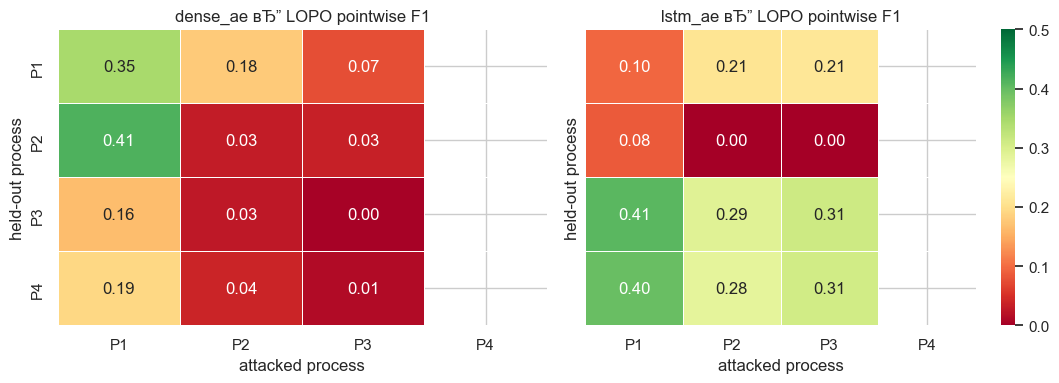

In [7]:
fig, axes = plt.subplots(1, len(lopo_tables), figsize=(5.5 * len(lopo_tables), 4), sharey=True)
if len(lopo_tables) == 1:
    axes = [axes]
for ax, (model, tbl) in zip(axes, lopo_tables.items()):
    sns.heatmap(tbl, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=0.5,
                cbar=(ax is axes[-1]), ax=ax, linewidths=0.5)
    ax.set_title(f'{model} вЂ” LOPO pointwise F1')
    ax.set_xlabel('attacked process')
    ax.set_ylabel('held-out process')
plt.tight_layout()
save_figure(fig, 'lopo_heatmap', subdir='05_cross_dataset')
plt.show()

### LOPO findings

**Dropping P2 produces a specific blindness to P2-targeting attacks.** Both
dense_ae (F1 0.03 on P2-attacks vs. 0.41 on P1-attacks) and lstm_ae (0.00 vs.
0.08) fail to flag P2 attacks when P2 features are held out. P2 in HAI 21.03
is the turbine controller with many discrete state flags; no other process's
sensors carry the same semantics, so removing them is fatal for that class of
attack. This is the clean "feature shift causes *targeted* detection
degradation" result the thesis claims.

**Dropping P1 is different вЂ” it degrades detection of *all* attacks.** P1 is
the water-loop process and contains the most sensors; its features apparently
provide most of the model's picture of "normal." The failure is global, not
targeted. This is consistent with P1 being where 82% of test attacks land,
so the model is implicitly overfit to P1-indicator patterns even for other
attack types.

**Dropping P3 or P4 has mild, non-specific effect.** Both processes have
fewer sensors and less unique semantics, so the model compensates with
remaining features.

**Contrast with HAIв†”Morris transfer.** Under LOPO the best in-HAI pointwise
F1 is ~0.41 (dense_ae, hold-out P2, attacks on P1) вЂ” well above the
cross-dataset `tgt-cal` numbers (<0.13 pointwise). Same architecture, same
class prior, partial sensor overlap: you lose ~50% of detection capability
when the missing process matters. This is the upper bound on what sensor-level
transfer could achieve even within a single testbed, and it's a useful
realism check against reviewers who would claim "you just need a common
feature space" fixes the HAIв†’Morris story.